## GOLD AND SILVER PRICE PREDICTION 

## TO FIND THE GOLD AND SILVER PRICE TAKE BY HISTORICAL DATA 

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

## 2. Load Dataset

In [2]:
df = pd.read_csv("Gold-Silver-Data.csv")
print(df.head())

         DATE  GOLD_PRICE  GOLD_OPEN  GOLD_HIGH  GOLD_LOW  GOLD_CHANGE_%  \
0  10/09/2025     3630.90    3633.61    3634.42   3620.90          -0.07   
1  09/09/2025     3633.61    3637.10    3674.75   3625.33          -0.06   
2  08/09/2025     3635.84    3586.82    3646.60   3579.67           1.24   
3  07/09/2025     3591.19    3592.07    3596.56   3586.95           0.12   
4  05/09/2025     3586.81    3547.00    3600.33   3540.05           1.15   

   SILVER_PRICE  SILVER_OPEN  SILVER_HIGH  SILVER_LOW  SILVER_CHANGE_%  
0         40.92        40.89        40.94       40.72             0.09  
1         40.89        41.34        41.50       40.77            -1.13  
2         41.36        41.01        41.68       40.51             1.20  
3         40.86        41.00        41.01       40.76            -0.34  
4         41.01        40.69        41.44       40.55             0.76  


## 3. Clean Column Names

In [3]:
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")
print(df.columns)

Index(['date', 'gold_price', 'gold_open', 'gold_high', 'gold_low',
       'gold_change_%', 'silver_price', 'silver_open', 'silver_high',
       'silver_low', 'silver_change_%'],
      dtype='object')


In [4]:
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10571 entries, 0 to 10570
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   date             10571 non-null  object 
 1   gold_price       10571 non-null  float64
 2   gold_open        10571 non-null  float64
 3   gold_high        10571 non-null  float64
 4   gold_low         10571 non-null  float64
 5   gold_change_%    10571 non-null  float64
 6   silver_price     10564 non-null  float64
 7   silver_open      10564 non-null  float64
 8   silver_high      10564 non-null  float64
 9   silver_low       10564 non-null  float64
 10  silver_change_%  10564 non-null  float64
dtypes: float64(10), object(1)
memory usage: 908.6+ KB
None
         gold_price     gold_open     gold_high      gold_low  gold_change_%  \
count  10571.000000  10571.000000  10571.000000  10571.000000   10571.000000   
mean     887.276856    887.412518    892.378187    881.901980       0.028

## 4. Handle Missing Values

In [5]:
df = df.fillna(method='ffill')

C:\Users\hp\AppData\Local\Temp\ipykernel_17096\569672361.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='ffill')


## 5. Visualization

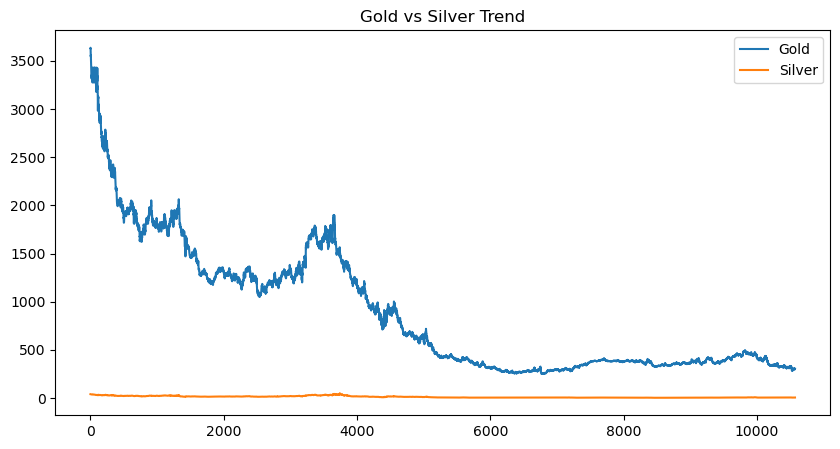

In [6]:
gold_col = [col for col in df.columns if 'gold' in col][0]
silver_col = [col for col in df.columns if 'silver' in col][0]

plt.figure(figsize=(10,5))
plt.plot(df[gold_col], label='Gold')
plt.plot(df[silver_col], label='Silver')

plt.legend()
plt.title("Gold vs Silver Trend")
plt.show()

## 6. Distribution Plots

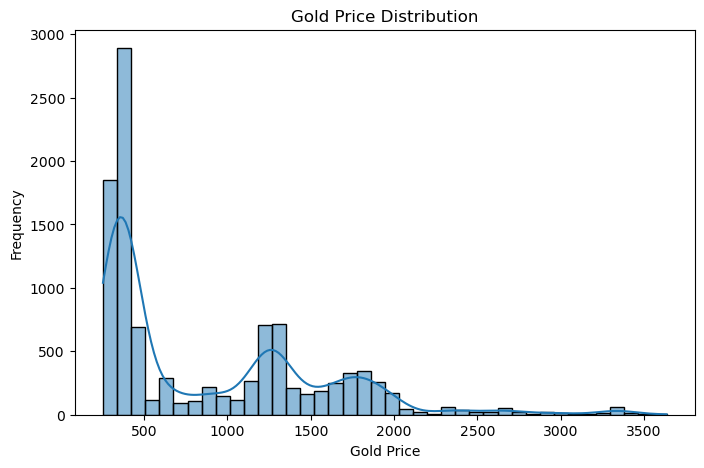

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.histplot(df['gold_price'], kde=True)

plt.title("Gold Price Distribution")
plt.xlabel("Gold Price")
plt.ylabel("Frequency")

plt.show()

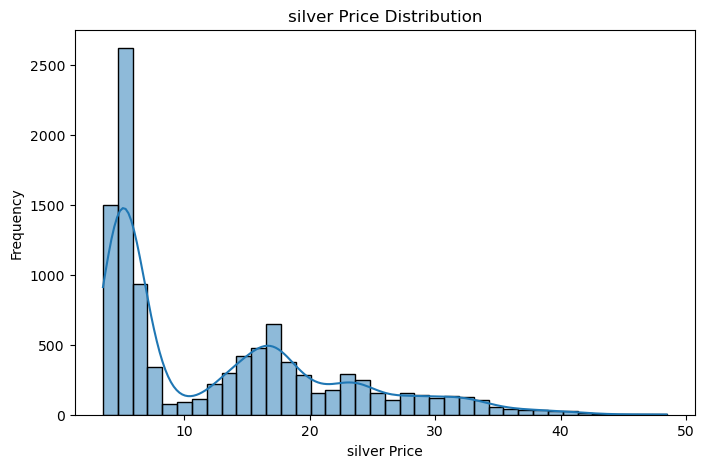

In [8]:
plt.figure(figsize=(8,5))

sns.histplot(df['silver_price'], kde=True)

plt.title("silver Price Distribution")
plt.xlabel("silver Price")
plt.ylabel("Frequency")

plt.show()

## 7 Correlation

C:\Users\hp\AppData\Local\Temp\ipykernel_17096\3847567880.py:4: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df[col] = pd.to_numeric(df[col], errors='ignore')
C:\Users\hp\AppData\Local\Temp\ipykernel_17096\3847567880.py:4: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df[col] = pd.to_numeric(df[col], errors='ignore')
C:\Users\hp\AppData\Local\Temp\ipykernel_17096\3847567880.py:4: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df[col] = pd.to_numeric(df[col], errors='ignore')
C:\Users\hp\AppData\Local\Temp\ipykernel_17096\3847567880.py:4: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without p

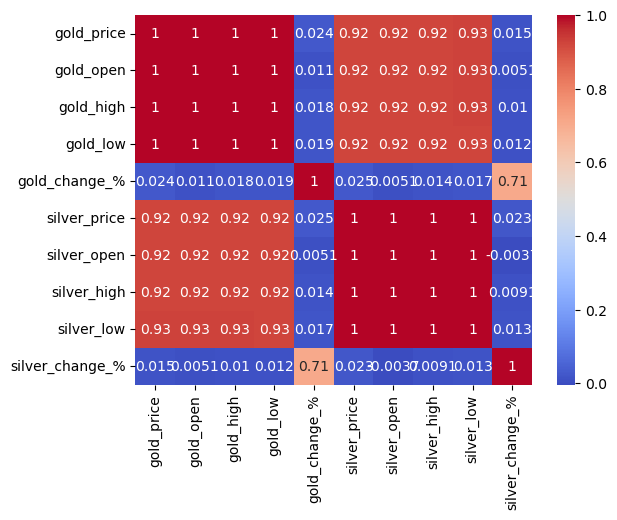

In [9]:
# convert all possible numeric columns
for col in df.columns:
    df[col] = df[col].astype(str).str.replace(',', '')
    df[col] = pd.to_numeric(df[col], errors='ignore')

# keep only numeric
df_numeric = df.select_dtypes(include=['number'])

# drop nulls
df_numeric = df_numeric.dropna()

# plot
sns.heatmap(df_numeric.corr(), annot=True, cmap='coolwarm')
plt.show()

## 8 Define Features & Target

In [10]:
# auto detect gold column
gold_col = [col for col in df.columns if 'gold' in col][0]

# convert to numeric
df[gold_col] = pd.to_numeric(df[gold_col], errors='coerce')

# drop nulls
df = df.dropna()

# define X and y
y = df[gold_col]
X = df.drop(columns=[gold_col])

# keep only numeric features
X = X.select_dtypes(include=['number'])

print("Features:", X.columns)
print("Target:", gold_col)

Features: Index(['gold_open', 'gold_high', 'gold_low', 'gold_change_%', 'silver_price',
       'silver_open', 'silver_high', 'silver_low', 'silver_change_%'],
      dtype='object')
Target: gold_price


## 9 Train-Test Split

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## 10 Linear Regression (Baseline)

In [12]:
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

## Evaluate

In [13]:
r2_lr = r2_score(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))

print("Linear Regression R2:", r2_lr)
print("Linear Regression RMSE:", rmse_lr)

Linear Regression R2: 0.9999757739394189
Linear Regression RMSE: 3.3152675399720404


## 11 XGBoost Model

In [14]:
xgb = XGBRegressor()
xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

## Evaluate

In [15]:
r2_xgb = r2_score(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))

print("XGBoost R2:", r2_xgb)
print("XGBoost RMSE:", rmse_xgb)

XGBoost R2: 0.9997934687856487
XGBoost RMSE: 9.679881288794547


## 12 LightGBM Model

In [16]:
lgbm = LGBMRegressor()
lgbm.fit(X_train, y_train)

y_pred_lgbm = lgbm.predict(X_test)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000453 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2295
[LightGBM] [Info] Number of data points in the train set: 8456, number of used features: 9
[LightGBM] [Info] Start training from score 885.398316


## Evaluate

In [17]:
r2_lgbm = r2_score(y_test, y_pred_lgbm)
rmse_lgbm = np.sqrt(mean_squared_error(y_test, y_pred_lgbm))

print("LightGBM R2:", r2_lgbm)
print("LightGBM RMSE:", rmse_lgbm)

LightGBM R2: 0.999802357893082
LightGBM RMSE: 9.469279148123059


## 13 Compare Models

In [18]:
results = pd.DataFrame({
    "Model": ["Linear", "XGBoost", "LightGBM"],
    "R2 Score": [r2_lr, r2_xgb, r2_lgbm],
    "RMSE": [rmse_lr, rmse_xgb, rmse_lgbm]
})

print(results)

      Model  R2 Score      RMSE
0    Linear  0.999976  3.315268
1   XGBoost  0.999793  9.679881
2  LightGBM  0.999802  9.469279


## 14 Select Best Model

In [19]:
best_model = lgbm   # or xgb based on results

## 15 Prediction

In [20]:
# Create empty dictionary
user_input = {}

# Take input for each feature
for col in X.columns:
    value = float(input(f"Enter value for {col}: "))
    user_input[col] = [value]

# Convert to DataFrame
new_data = pd.DataFrame(user_input)

# Prediction
prediction = best_model.predict(new_data)

print("Predicted Gold Price:", prediction[0])

Enter value for gold_open:  234235
Enter value for gold_high:  2453465
Enter value for gold_low:  64
Enter value for gold_change_%:  65
Enter value for silver_price:  6000
Enter value for silver_open:  9000
Enter value for silver_high:  999
Enter value for silver_low:  888
Enter value for silver_change_%:  9


Predicted Gold Price: 1800.3786891355421


In [21]:
# STEP 1: Define target as SILVER

silver_col = [col for col in df.columns if 'silver' in col][0]

y = df[silver_col]
X = df.drop(columns=[silver_col])

# keep only numeric features
X = X.select_dtypes(include=['number'])

# STEP 2: Train model (if not already)
from sklearn.model_selection import train_test_split
from lightgbm import LGBMRegressor

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

best_model = LGBMRegressor()
best_model.fit(X_train, y_train)

# STEP 3: Take USER INPUT

user_input = {}

for col in X.columns:
    value = float(input(f"Enter value for {col}: "))
    user_input[col] = [value]
# STEP 4: Convert to DataFrame

new_data = pd.DataFrame(user_input)

# STEP 5: Prediction

prediction = best_model.predict(new_data)

# STEP 6: Output

print("Predicted Silver Price:", prediction[0])

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000399 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2295
[LightGBM] [Info] Number of data points in the train set: 8456, number of used features: 9
[LightGBM] [Info] Start training from score 12.809134


Enter value for gold_price:  50000
Enter value for gold_open:  4000
Enter value for gold_high:  66
Enter value for gold_low:  877
Enter value for gold_change_%:  5
Enter value for silver_open:  23434
Enter value for silver_high:  24534
Enter value for silver_low:  2453
Enter value for silver_change_%:  245


Predicted Silver Price: 45.32791697346169


## 16 Save Model

In [22]:
import joblib
joblib.dump(best_model, "gold_model.pkl")

['gold_model.pkl']

## Load model

 model = joblib.load("gold_model.pkl")